In [27]:

!apt-get install -y r-base


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.1-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [28]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [29]:
%%R
dados <- read.csv("https://raw.githubusercontent.com/JOAO-PEDRO-ROLIM-XIMENES/homework-da-mimi/refs/heads/main/HW1_bike_sharing.csv")
head(dados)


  X instant     dteday season weathersit temp casual registered
1 1       1 2011-01-01      1          2 14.1    331        654
2 2       2 2011-01-02      1          2 14.9    131        670
3 3       3 2011-01-03      1          1  8.1    120       1229
4 4       4 2011-01-04      1          1  8.2    108       1454
5 5       5 2011-01-05      1          1  9.3     82       1518
6 6       6 2011-01-06      1          1  8.4     88       1518


In [30]:
%%R
dados$dteday <- as.Date(dados$dteday)
min(dados$dteday)





[1] "2011-01-01"


In [31]:
%%R
dados$dteday <- as.Date(dados$dteday)
max(dados$dteday)

[1] "2012-12-31"


In [32]:
%%R
nrow(dados)


[1] 731


In [33]:
%%R
num_vars <- c("instant", "temp", "casual", "registered")

summary_table <- data.frame(
  Variável = num_vars,
  Média = sapply(dados[num_vars], mean, na.rm = TRUE),
  Mediana = sapply(dados[num_vars], median, na.rm = TRUE),
  Q1 = sapply(dados[num_vars], quantile, probs = 0.25, na.rm = TRUE),
  Q3 = sapply(dados[num_vars], quantile, probs = 0.75, na.rm = TRUE)
)

print(summary_table, row.names = FALSE)


   Variável      Média Mediana     Q1     Q3
    instant  366.00000   366.0  183.5  548.5
       temp   20.31122    20.4   13.8   26.9
     casual  848.17647   713.0  315.5 1096.0
 registered 3656.17237  3662.0 2497.0 4776.5


In [34]:
%%R
library(ggplot2)
library(dplyr)
dados$total_users <- dados$casual + dados$registered
dados$season <- factor(dados$season,
                       levels = c(1, 2, 3, 4),
                       labels = c("inverno", "primavera", "verão", "outono"))

dados$weathersit <- factor(dados$weathersit,
                           levels = c(1, 2, 3, 4),
                           labels = c("Céu limpo", "Nublado", "Chuva fraca", "Chuva forte"))
head(dados)


  X instant     dteday  season weathersit temp casual registered total_users
1 1       1 2011-01-01 inverno    Nublado 14.1    331        654         985
2 2       2 2011-01-02 inverno    Nublado 14.9    131        670         801
3 3       3 2011-01-03 inverno  Céu limpo  8.1    120       1229        1349
4 4       4 2011-01-04 inverno  Céu limpo  8.2    108       1454        1562
5 5       5 2011-01-05 inverno  Céu limpo  9.3     82       1518        1600
6 6       6 2011-01-06 inverno  Céu limpo  8.4     88       1518        1606


# A tibble: 4 × 2
  season    Media_usuarios
  <fct>              <dbl>
1 inverno            2604.
2 primavera          4992.
3 verão              5644.
4 outono             4728.


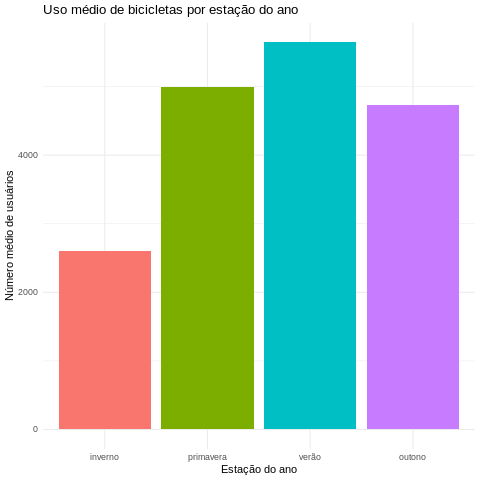

In [35]:
%%R
uso_por_estacao <- dados %>%
  group_by(season) %>%
  summarise(Media_usuarios = mean(total_users, na.rm = TRUE))
print(uso_por_estacao)
ggplot(uso_por_estacao, aes(x = season, y = Media_usuarios, fill = season)) +
  geom_bar(stat = "identity") +
  labs(title = "Uso médio de bicicletas por estação do ano",
       x = "Estação do ano", y = "Número médio de usuários") +
  theme_minimal() +
  theme(legend.position = "none")


# A tibble: 3 × 2
  weathersit  Media_usuarios
  <fct>                <dbl>
1 Céu limpo            4877.
2 Nublado              4036.
3 Chuva fraca          1803.


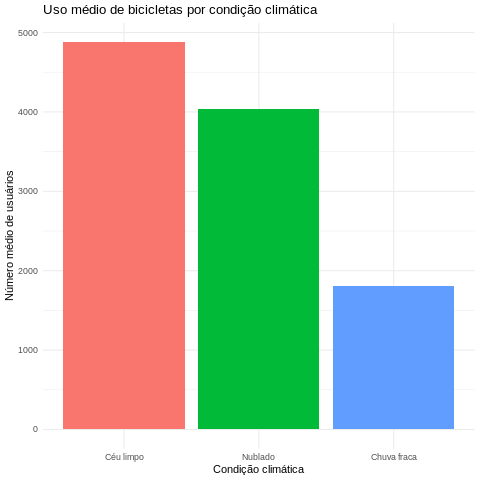

In [36]:
%%R
uso_por_clima <- dados %>%
  group_by(weathersit) %>%
  summarise(Media_usuarios = mean(total_users, na.rm = TRUE))
print(uso_por_clima)
ggplot(uso_por_clima, aes(x = weathersit, y = Media_usuarios, fill = weathersit)) +
  geom_bar(stat = "identity") +
  labs(title = "Uso médio de bicicletas por condição climática",
       x = "Condição climática", y = "Número médio de usuários") +
  theme_minimal() +
  theme(legend.position = "none")


In [37]:
%%R
# Cria variável de total de usuários por dia
dados$total_users <- dados$casual + dados$registered

# Converte temperatura normalizada para temperatura real (em °C)
dados$temp_real <- dados$temp * 41


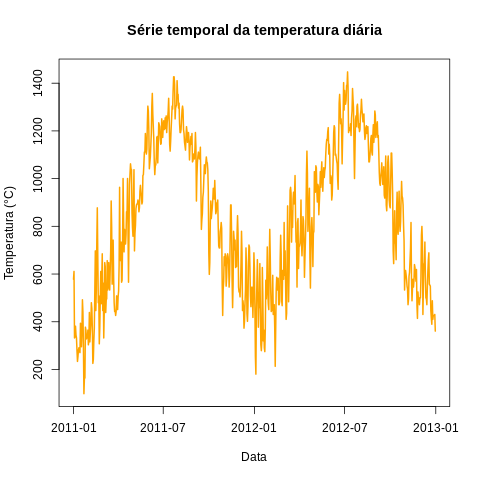

In [38]:
%%R
# Gráfico da série temporal de temperatura real
plot(dados$dteday, dados$temp_real, type = "l", col = "orange", lwd = 2,
     xlab = "Data", ylab = "Temperatura (°C)",
     main = "Série temporal da temperatura diária")


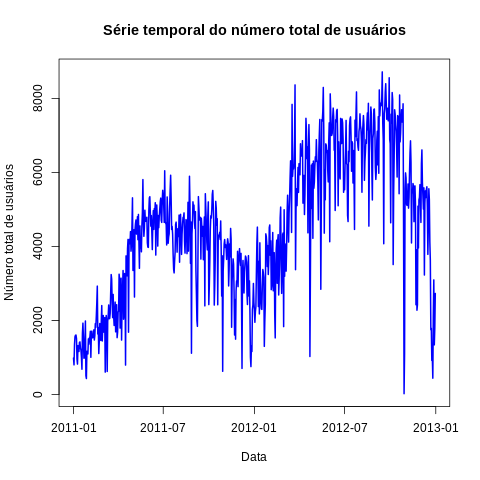

In [39]:
%%R
# Gráfico da série temporal do total de usuários
plot(dados$dteday, dados$total_users, type = "l", col = "blue", lwd = 2,
     xlab = "Data", ylab = "Número total de usuários",
     main = "Série temporal do número total de usuários")
